# Anomaly attribution model for MOTS

## Flow:
- Model intakes list of species counts per 7 species
- Model performs anomaly attribution
- Model returns list of species and how much each species contributed to the total anomaly, as well as a total anomaly value

In [1]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.patches import Patch

In [2]:
# read data
# df = pd.read_csv('The_43_BRS_surveys_species_count.txt')
df = pd.read_csv('4shark_surveys_species_count.csv')

In [3]:
df

,species_name,Survey 1,Survey 2,Survey 3,Survey 4,Survey 5,Survey 6,Survey 7,Survey 8,Survey 9,...,Survey 797,Survey 798,Survey 799,Survey 800,Survey 801,Survey 802,Survey 803,Survey 804,Survey 805,Survey 806
0,Ctenochaetus striatus,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,3,0,0
1,Chlorurus sordidus,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Labroides dimidiatus,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,4,3,2,3,1
3,Thalassoma lutescens,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Acanthurus nigrofuscus,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1205,Taeniamia biguttata,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1206,Taeniamia melasma,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1207,Aipysurus spp.,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1208,Zapteryx xyster,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


- The data as opened above is in the format of species rows and survey columns.
- This data needs thus needs to be transposed and raveled so that the species are columns and the surveys are rows.
- This is because features are expected to be columns and one sample in rows!
- When the data is ravelled, one row will represent one survey, and each field per column will be marked with 0 or a count of the number of species observed in that survey.

In [4]:
df_T = df.set_index("species_name").T

df_T.index.name = None
df_T = df_T.reset_index(drop=True)
df_T = df_T.rename_axis(None, axis=1)

print(df_T.shape)

(806, 1210)


In [5]:
df = df_T
del df_T
df

,Ctenochaetus striatus,Chlorurus sordidus,Labroides dimidiatus,Thalassoma lutescens,Acanthurus nigrofuscus,Thalassoma lunare,Gomphosus varius,Halichoeres hortulanus,Zebrasoma scopas,Parupeneus multifasciatus,...,Isocirrhitus sexfasciatus,Istigobius goldmanni,Goniistius plessisi,Gorgasia galzini,Synodus capricornis,Taeniamia biguttata,Taeniamia melasma,Aipysurus spp.,Zapteryx xyster,Acanthemblemaria atrata
0,1,0,1,0,0,5,2,0,1,3,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
801,1,0,4,0,1,6,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
802,0,0,3,0,0,3,1,0,2,0,...,0,0,0,0,0,0,0,0,0,0
803,3,0,2,0,0,2,1,4,1,0,...,0,0,0,0,0,0,0,0,0,0
804,0,0,3,0,0,8,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


- Basically, the data is now count vectorised (wow thats crazy... the data collection method produced this...)
- This can either be fed in as a cv or re-vectorised to other vectors like tfidf or ohe

# Grouping

- YH fully performed the selection and grouping of the fish roles into a few distinct groups, described in a spec sheet.
- The df will painstakingly be filtered and grouped according to the specifications in his document provided here:

In [6]:
print([col for col in df.columns])

['Ctenochaetus striatus', 'Chlorurus sordidus', 'Labroides dimidiatus', 'Thalassoma lutescens', 'Acanthurus nigrofuscus', 'Thalassoma lunare', 'Gomphosus varius', 'Halichoeres hortulanus', 'Zebrasoma scopas', 'Parupeneus multifasciatus', 'Thalassoma hardwicke', 'Acanthochromis polyacanthus', 'Pomacentrus vaiuli', 'Stegastes lacrymatus', 'Pycnochromis margaritifer', 'Zanclus cornutus', 'Ctenochaetus binotatus', 'Anampses neoguinaicus', 'Bodianus diplotaenia', 'Acanthurus nigricans', 'Centropyge bispinosa', 'Dascyllus reticulatus', 'Triaenodon obesus', 'Pycnochromis iomelas', 'Pomacentrus moluccensis', 'Thalassoma lucasanum', 'Scarus niger', 'Chlorurus microrhinos', 'Chaetodon pelewensis', 'Thalassoma amblycephalum', 'Paranthias colonus', 'Halichoeres biocellatus', 'Amblyglyphidodon curacao', 'Scolopsis bilineata', 'Caranx melampygus', 'Pseudocheilinus hexataenia', 'Forcipiger flavissimus', 'Amblyglyphidodon leucogaster', 'Scarus schlegeli', 'Scarus rubroviolaceus', 'Paracirrhites arcatu

In [7]:
# 1. APEX PREDATORS
APEX_PREDATORS = [
    "Carcharhinus melanopterus",   # Explicitly, Blacktip Reef Shark
    'Triaenodon obesus',  # Whitetip Reef Shark
    'Carcharhinus amblyrhynchos',  # Grey Reef Shark
    'Carcharhinus albimarginatus',  # Silvertip Shark
]

# 2. HERBIVORE SCRAPERS
HERBIVORE_SCRAPERS = [
    "Chlorurus sordidus",       # Bullethead Parrotfish  (primary, 38/43)
    "Chlorurus microrhinos",    # Steephead Parrotfish   (substitute survey 43)
    "Scarus niger",             # Swarthy Parrotfish     (substitute survey 30)
    # Pacific Longnose Parrotfish (substitute survey 36)
    "Hipposcarus longiceps",
    "Scarus ghobban",           # Blue-barred Parrotfish (substitute survey 27)
    "Scarus flavipectoralis",   # Yellow-fin Parrotfish  (substitute survey 42)
]

# 3. CARNIVOROUS CLEANERS
CARNIVOROUS_CLEANERS = [
    "Labroides dimidiatus",     # Bluestreak Cleaner Wrasse (primary, 38/43)
    # Bicolor Cleaner Wrasse  (substitute surveys 9,13,20)
    "Labroides bicolor",
    # Axilspot Hogfish        (substitute surveys 7,12)
    "Bodianus axillaris",
]

# 4. TURF BRUSHERS
TURF_BRUSHERS = [
    "Ctenochaetus striatus",    # Striated Surgeonfish    (primary, 28/43)
    # Whitetail Bristletooth  (substitute surveys 10,15,19,20)
    "Ctenochaetus flavicauda",
    # Twospot Bristletooth    (substitute surveys 6,23,35)
    "Ctenochaetus binotatus",
    # Brown Surgeonfish       (substitute surveys 25,40)
    "Acanthurus nigrofuscus",
    # Finelined Surgeonfish   (substitute surveys 31,32,36,38,39,41)
    "Acanthurus grammoptilus",
]

# 5. INVERTEBRATE PREY HUNTERS
INVERTEBRATE_PREY_HUNTERS = [
    "Parupeneus multifasciatus",  # Manybar Goatfish       (primary, 27/43)
    # Goldbody Goatfish      (substitute surveys 9,23)
    "Parupeneus cyclostomus",
    # Yellowspot Goatfish    (substitute surveys 31,36,40,41)
    "Parupeneus indicus",
    # Dash-and-dot Goatfish  (substitute survey 34)
    "Parupeneus barberinus",
    # Bicolor Goatfish       (substitute surveys 22,39)
    "Parupeneus barberinoides",
    # Blackspot Goatfish     (substitute survey 32)
    "Parupeneus spilurus",
    # Pacific Yellowtail Emperor (substitute surveys 21,38)
    "Lethrinus atkinsoni",
    # Blackeye Thicklip Wrasse  (substitute survey 33)
    "Hemigymnus melapterus",
    # Bigeye Emperor         (substitute survey 15)
    "Monotaxis grandoculis",
    # Redfin Emperor         (substitute survey 25)
    "Monotaxis heterodon",
    # Two-lined Monocle Bream   (substitute survey 42)
    "Scolopsis bilineata",
]

# 6. OBLIGATE CORALLIVORES
OBLIGATE_CORALLIVORES = [
    # Oval Butterflyfish           (primary, 22/43)
    "Chaetodon lunulatus",
    # Chevron Butterflyfish        (substitute surveys 20,22)
    "Chaetodon trifascialis",
    # Melon Butterflyfish          (substitute surveys 7,8,9)
    "Chaetodon trifasciatus",
    # Ornate Butterflyfish         (substitute surveys 3,19,27)
    "Chaetodon ornatissimus",
    # Mailed Butterflyfish         (substitute surveys 2,5,25)
    "Chaetodon reticulatus",
    # Harlequin Filefish         (substitute surveys 32,39,41)
    "Oxymonacanthus longirostris",
    # Threadfin Butterflyfish      (substitute survey 43)
    "Chaetodon auriga",
    # Eastern Triangular BF        (substitute surveys 24,31)
    "Chaetodon baronessa",
    # Golden Butterflyfish         (substitute surveys 21,33,36)
    "Chaetodon aureofasciatus",
    # Bluespot Butterflyfish       (substitute survey 38)
    "Chaetodon plebeius",
]

In [8]:
ROLE_MAP = {}
for sp in APEX_PREDATORS:
    ROLE_MAP[sp] = "Apex_Predators"
for sp in HERBIVORE_SCRAPERS:
    ROLE_MAP[sp] = "Herbivore_Scrapers"
# for sp in CARNIVOROUS_CLEANERS:
#     ROLE_MAP[sp] = "Carnivorous_Cleaners"
for sp in TURF_BRUSHERS:
    ROLE_MAP[sp] = "Turf_Brushers"
for sp in INVERTEBRATE_PREY_HUNTERS:
    ROLE_MAP[sp] = "Invertebrate_Prey_Hunters"
for sp in OBLIGATE_CORALLIVORES:
    ROLE_MAP[sp] = "Obligate_Corallivores"

ROLE_COLUMNS = [
    "Apex_Predators",
    "Herbivore_Scrapers",
    # "Carnivorous_Cleaners",
    "Turf_Brushers",
    "Invertebrate_Prey_Hunters",
    "Obligate_Corallivores",
]

In [9]:
def make_role_df(df, warn=True):
    df = df.copy()

    # check which species columns exist in the df
    all_role_species = list(ROLE_MAP.keys())
    present = [s for s in all_role_species if s in df.columns]
    missing = [s for s in all_role_species if s not in df.columns]

    if warn and missing:
        print("defined species absent from DataFrame:")
        for s in missing:
            print(f"   - {s}  [{ROLE_MAP[s]}]")

    # sum is used here instead of mean because the count of individuals in a role is the count of all species partaking of that role, not the average count per species.
    new_df = pd.DataFrame()
    for role in ROLE_COLUMNS:
        species_for_role = [s for s in ROLE_MAP if ROLE_MAP[s] == role and s in df.columns]
        new_df[role] = df[species_for_role].sum(axis=1) if species_for_role else 0

    return new_df

In [10]:
# use the func
df_with_roles = make_role_df(df, warn=True)

In [11]:
df_with_roles

,Apex_Predators,Herbivore_Scrapers,Turf_Brushers,Invertebrate_Prey_Hunters,Obligate_Corallivores
0,1,1,1,7,9
1,1,0,0,0,0
2,3,0,0,0,0
3,2,0,0,0,0
4,1,0,0,0,0
...,...,...,...,...,...
801,1,2,2,16,6
802,3,7,9,7,5
803,1,1,8,1,1
804,1,3,2,5,5


In [12]:
df = df_with_roles
del df_with_roles

- Further discussion also concluded with the following modifications:
    - Obligate_Corallivores is to be dropped due to its insignificance in contribution to the ecosystem of focus
    - Small_Invertebrates is to be added following the formula of Invertebrate_Prey_Hunters * 5 from prior research. This is done because the dataset only focused on general fish species

In [13]:
# drop obligate corallivores role
df = df.drop(columns=['Obligate_Corallivores'])

In [14]:
# add small invertebrates role
df['Small_Invertebrates'] = df['Invertebrate_Prey_Hunters'] * 5
df

,Apex_Predators,Herbivore_Scrapers,Turf_Brushers,Invertebrate_Prey_Hunters,Small_Invertebrates
0,1,1,1,7,35
1,1,0,0,0,0
2,3,0,0,0,0
3,2,0,0,0,0
4,1,0,0,0,0
...,...,...,...,...,...
801,1,2,2,16,80
802,3,7,9,7,35
803,1,1,8,1,5
804,1,3,2,5,25


<hr>

# EDA

- right off the bat, there is very little data. there are only 43 rows of data in a 7 dimensional space.
- nevertheless, this is all the data we could obtain...

## Classes

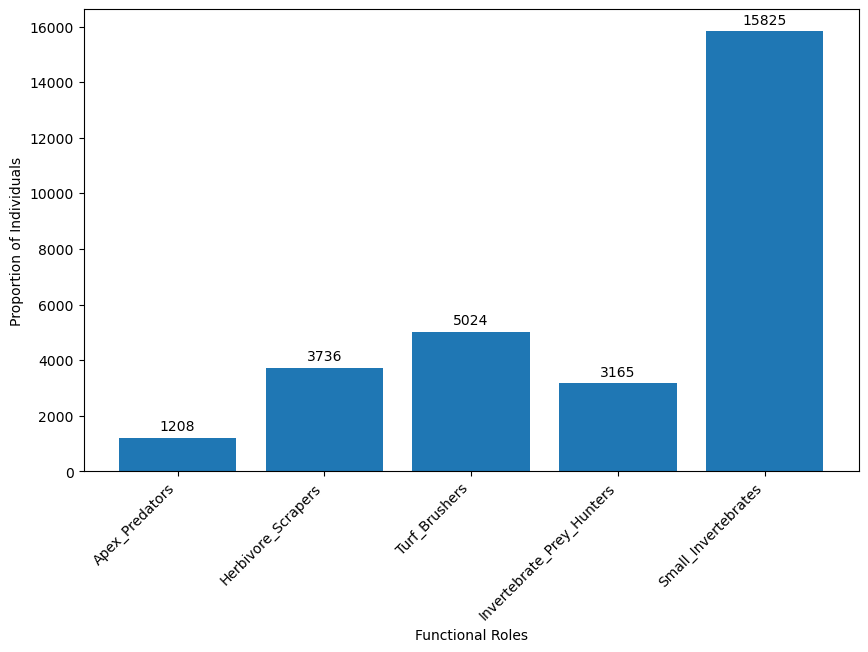

In [15]:
# proportions of roles:
plt.figure(figsize=(10, 6))

x = df.sum(axis=0).index
y = df.sum(axis=0).values

plt.xlabel("Functional Roles")
plt.ylabel("Proportion of Individuals")
plt.xticks(rotation=45, ha='right')

bars = plt.bar(x, y)

plt.bar_label(bars, labels=[f"{int(v)}" for v in y], padding=3)

plt.show()

In [16]:
def prop_stack(df):
    # norma such that each row sums to 1 (df_proportions.sum(axis=1) == 1)
    df_proportions = df.div(df.sum(axis=1), axis=0)
    ax = df_proportions.plot(kind='bar', stacked=True, figsize=(35, 15), width=1)
    plt.legend(title='Species Features', bbox_to_anchor=(
        1.02, 1), loc='upper left', borderaxespad=0)
    plt.title("Proportions of Functional Roles Across Surveys")
    plt.xlabel("Survey No.")
    plt.ylabel("Proportion of Individuals %")
    plt.yticks(np.arange(0, 1.1, 0.1), [
            f"{int(i*100)}%" for i in np.arange(0, 1.1, 0.1)])
    # for container in ax.containers:
    #     labels = [f'{val * 100:.1f}' if val > 0 else '' for val in container.datavalues]
    #     ax.bar_label(container, labels=labels, label_type='center', color='white', fontweight='bold', fontsize=8)
    plt.show()

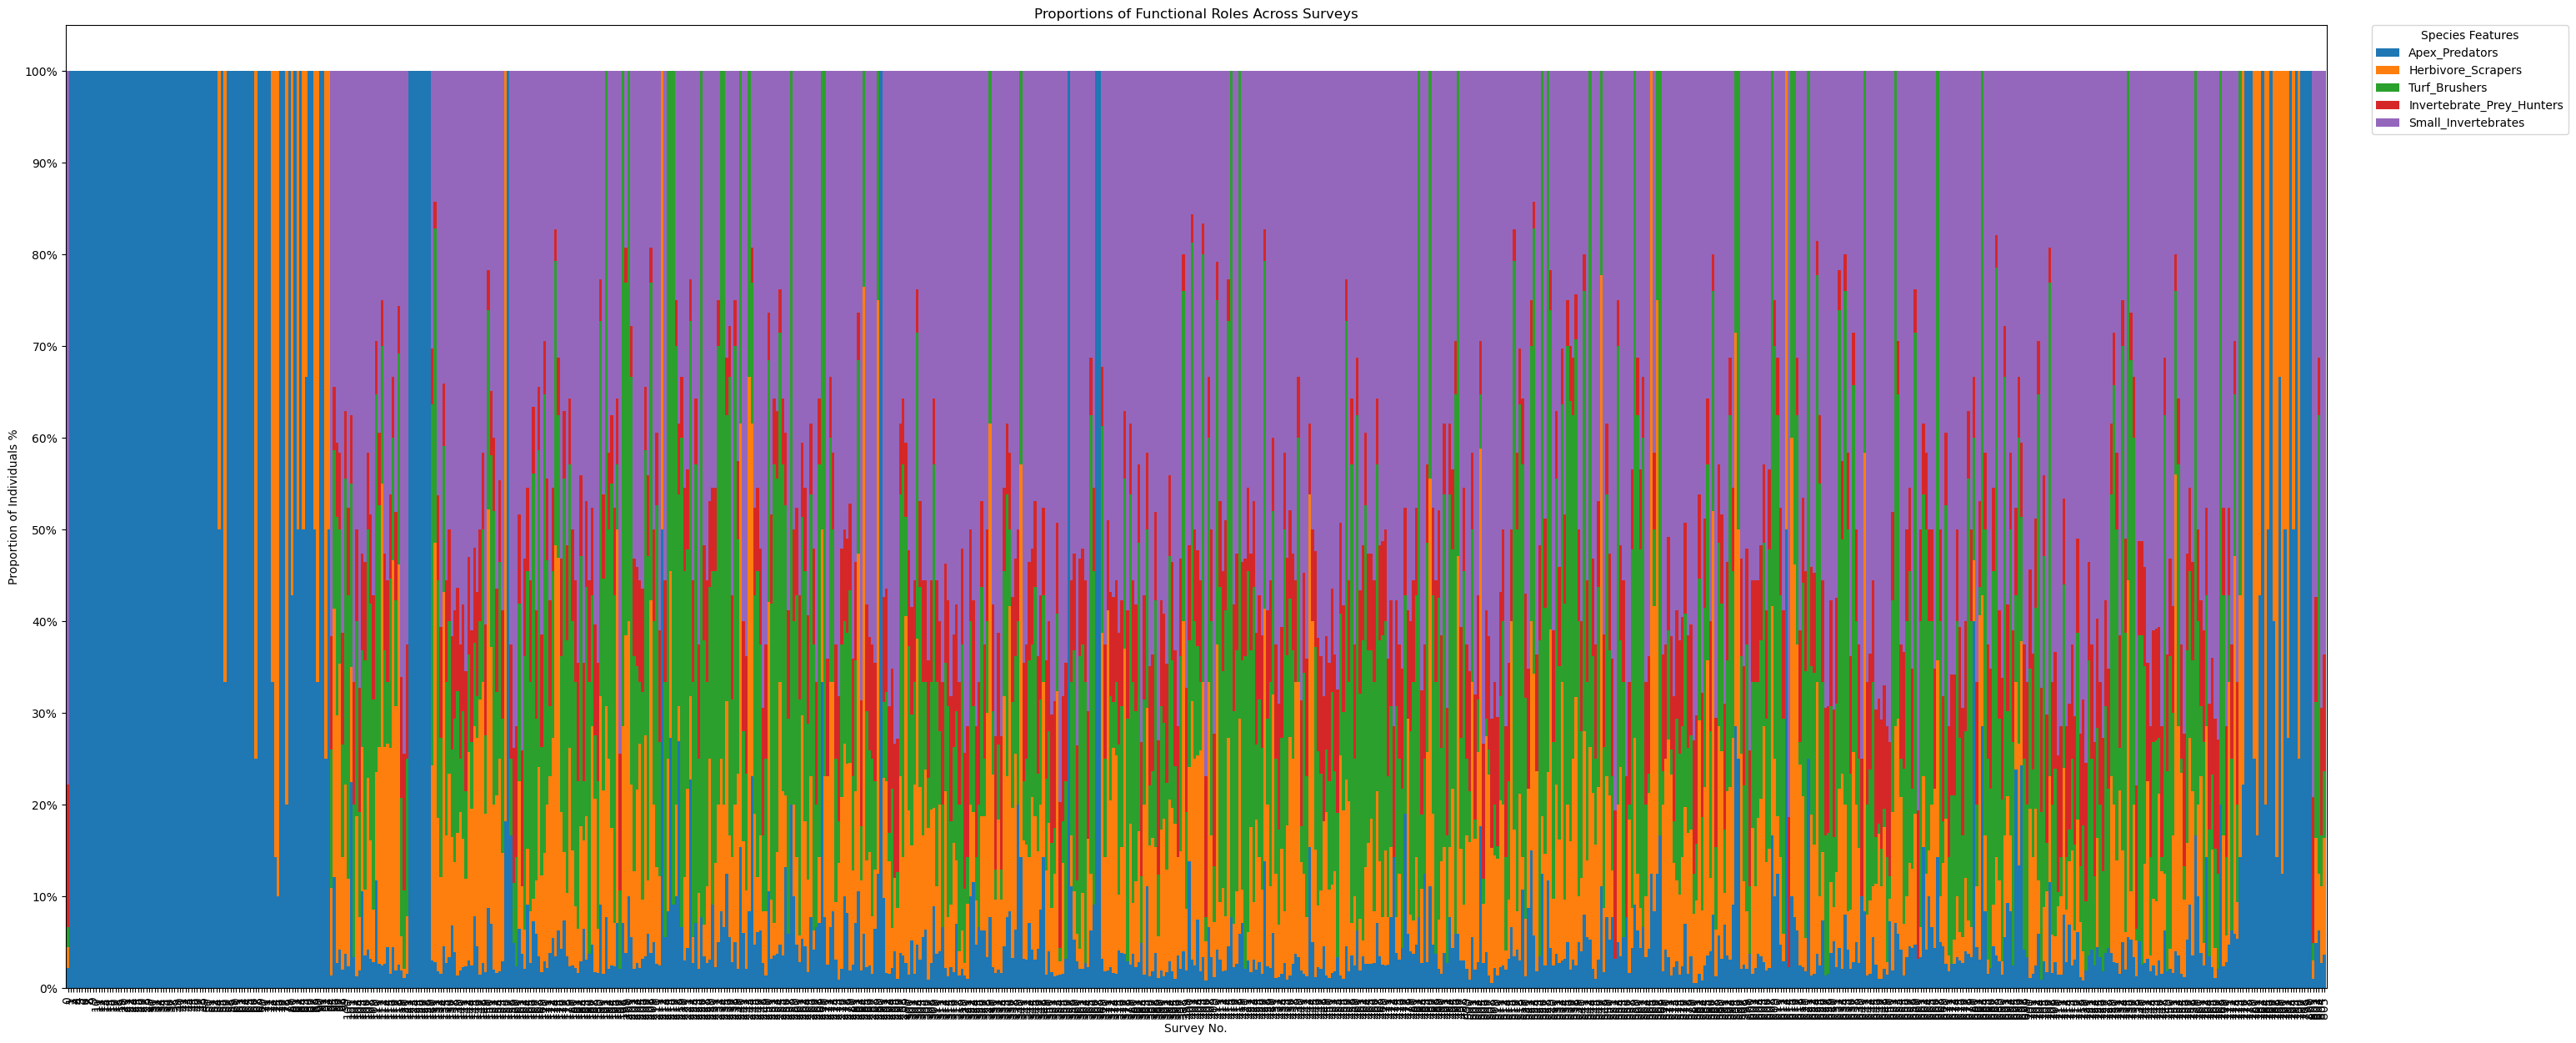

In [17]:
# role proportions per each survey
prop_stack(df)

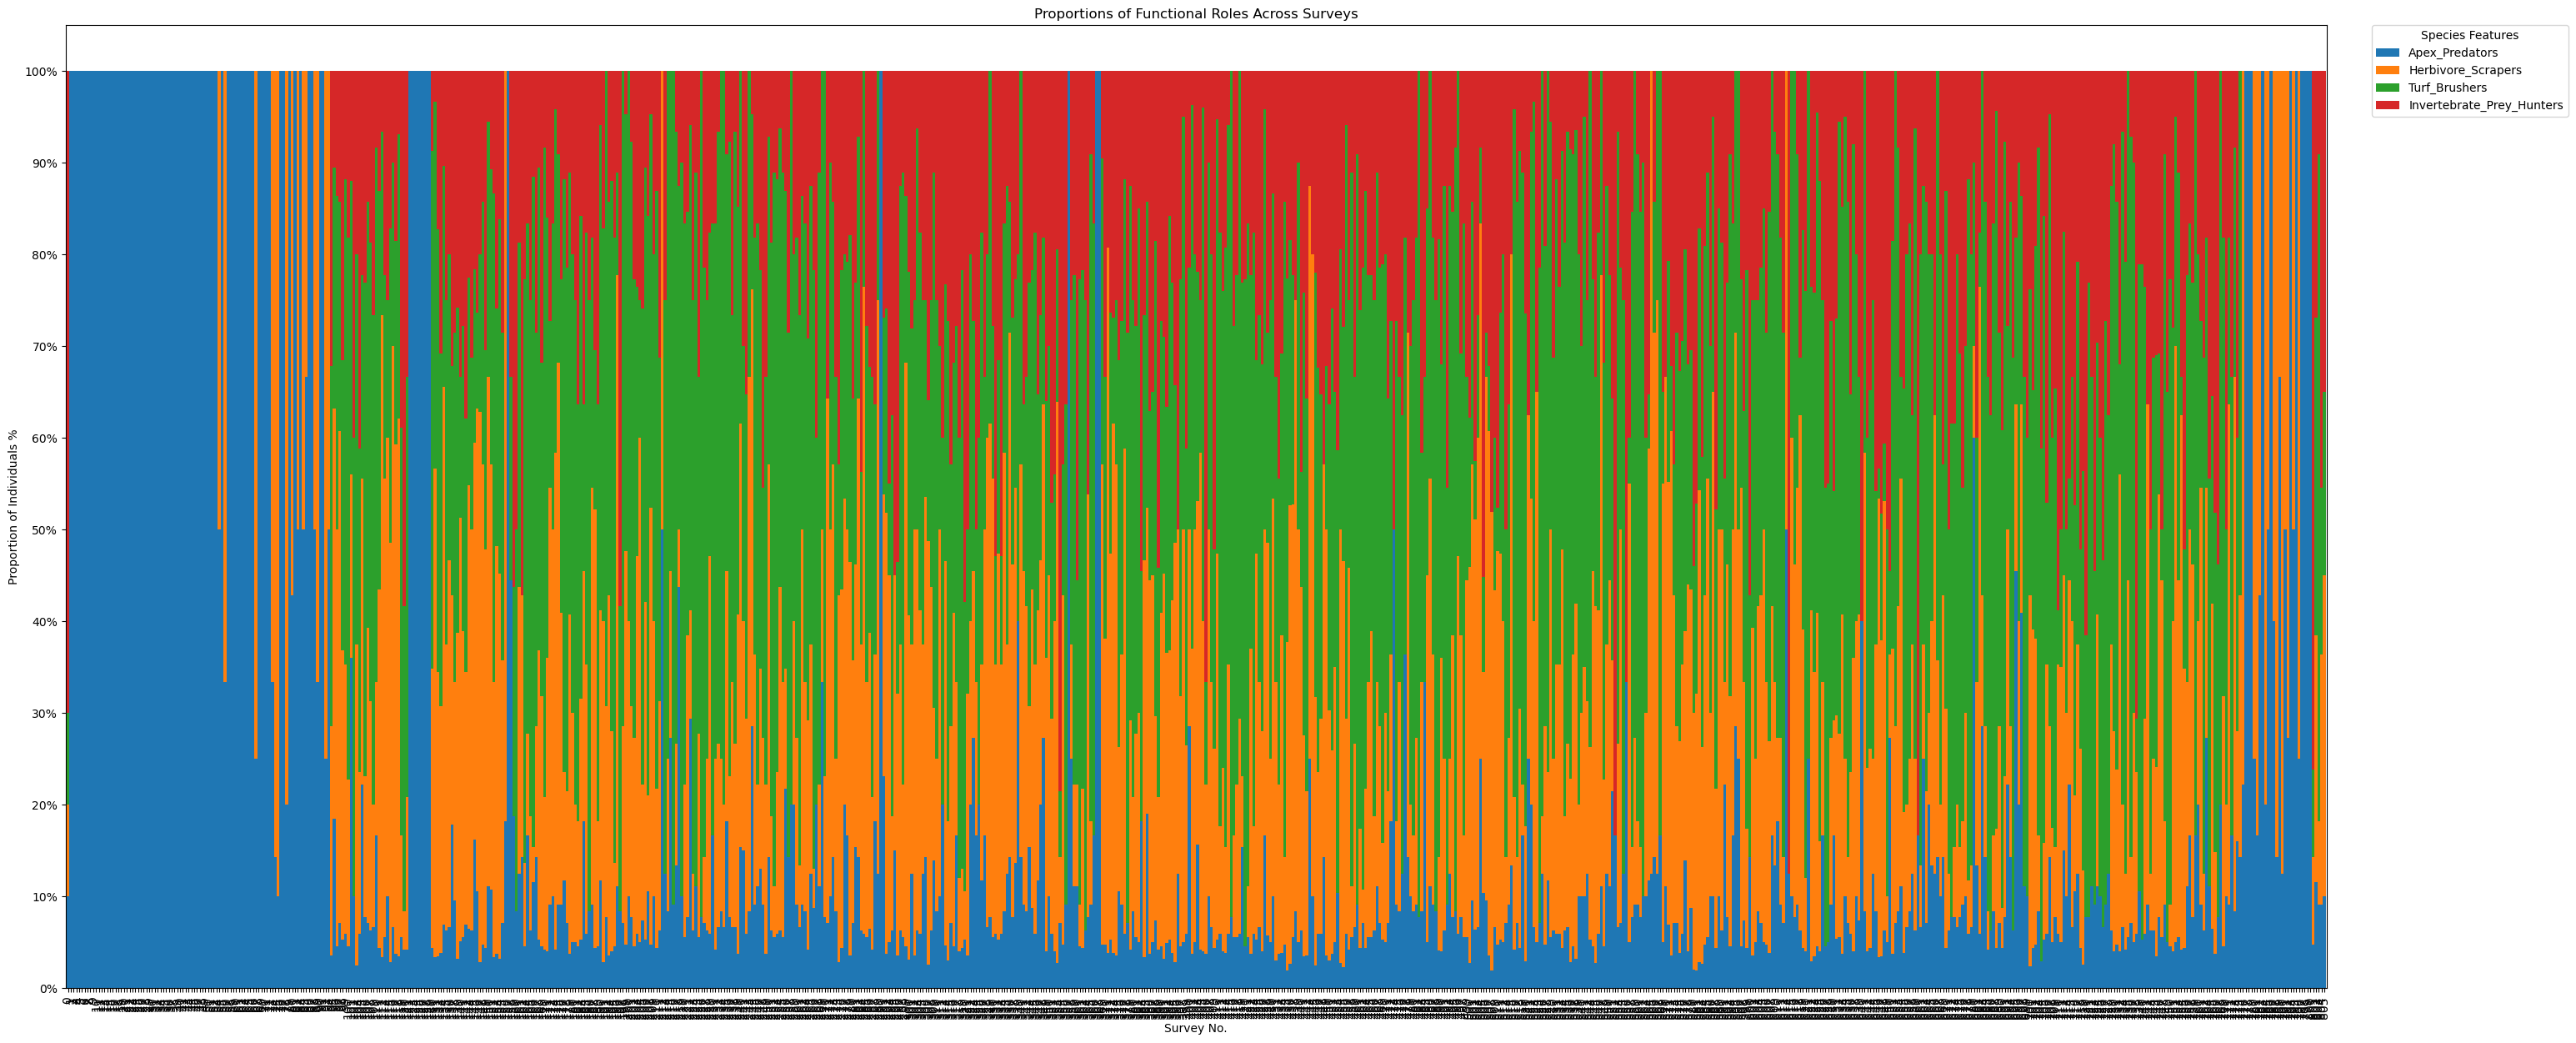

In [18]:
# role proportions of all surveys excluding small invertebrates
prop_stack(df.drop(columns=['Small_Invertebrates']))

- Some surveys seem to only contain apex predators..?

In [19]:
# sort surveys by proportion of apex predators, not count
# formula is apex pred / the row sum = apex prop:
df.drop("Apex_Proportion", axis=1, inplace=True, errors='ignore')  # drop if exists
df['Apex_Proportion'] = df['Apex_Predators'] / df.sum(axis=1)
df = df.sort_values(by="Apex_Proportion", ascending=False)
display(df[df['Apex_Proportion'] > 0.75])

,Apex_Predators,Herbivore_Scrapers,Turf_Brushers,Invertebrate_Prey_Hunters,Small_Invertebrates,Apex_Proportion
800,1,0,0,0,0,1.0
783,2,0,0,0,0,1.0
779,1,0,0,0,0,1.0
778,2,0,0,0,0,1.0
27,5,0,0,0,0,1.0
...,...,...,...,...,...,...
6,4,0,0,0,0,1.0
3,2,0,0,0,0,1.0
4,1,0,0,0,0,1.0
798,1,0,0,0,0,1.0


- These rows must be removed sadly... dropping the col count down even more

In [20]:
# drop all rows where apex prop > 0.75
df = df[df['Apex_Proportion'] <= 0.75]
print(df.shape)
df.drop("Apex_Proportion", axis=1, inplace=True, errors='ignore')  # no longer needed

(704, 6)


In [21]:
df

,Apex_Predators,Herbivore_Scrapers,Turf_Brushers,Invertebrate_Prey_Hunters,Small_Invertebrates
789,2,1,0,0,0
85,2,1,0,0,0
794,1,1,0,0,0
212,1,1,0,0,0
785,1,1,0,0,0
...,...,...,...,...,...
583,1,9,12,16,80
719,1,4,17,17,85
508,1,26,0,25,125
581,1,16,11,25,125


## Statistics

In [22]:
df.describe()

,Apex_Predators,Herbivore_Scrapers,Turf_Brushers,Invertebrate_Prey_Hunters,Small_Invertebrates
count,704.000000,704.000000,704.000000,704.000000,704.000000
mean,1.444602,5.306818,7.136364,4.495739,22.478693
std,0.986278,4.558413,4.635338,3.858815,19.294074
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,2.000000,4.000000,2.000000,10.000000
50%,1.000000,4.000000,7.000000,4.000000,20.000000
75%,2.000000,8.000000,10.000000,6.000000,30.000000
max,9.000000,26.000000,33.000000,27.000000,135.000000


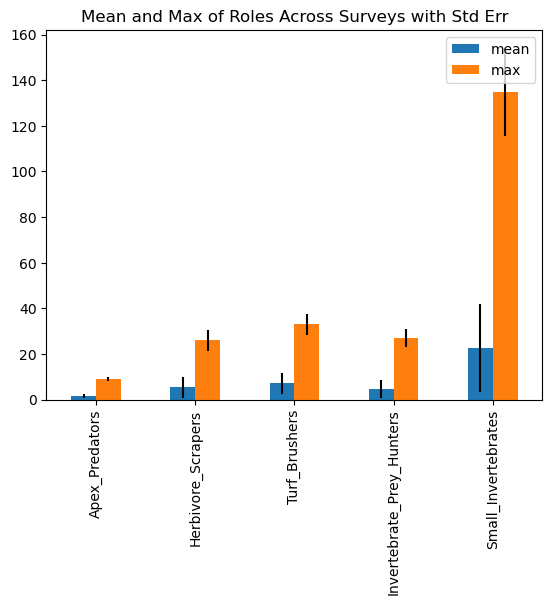

In [23]:
stats = df.describe().T

stats[['mean', 'max']].plot(kind='bar', yerr=stats['std'])  # the std here visually means how much the mean of each role varies across surveys.
plt.title("Mean and Max of Roles Across Surveys with Std Err")
plt.show()

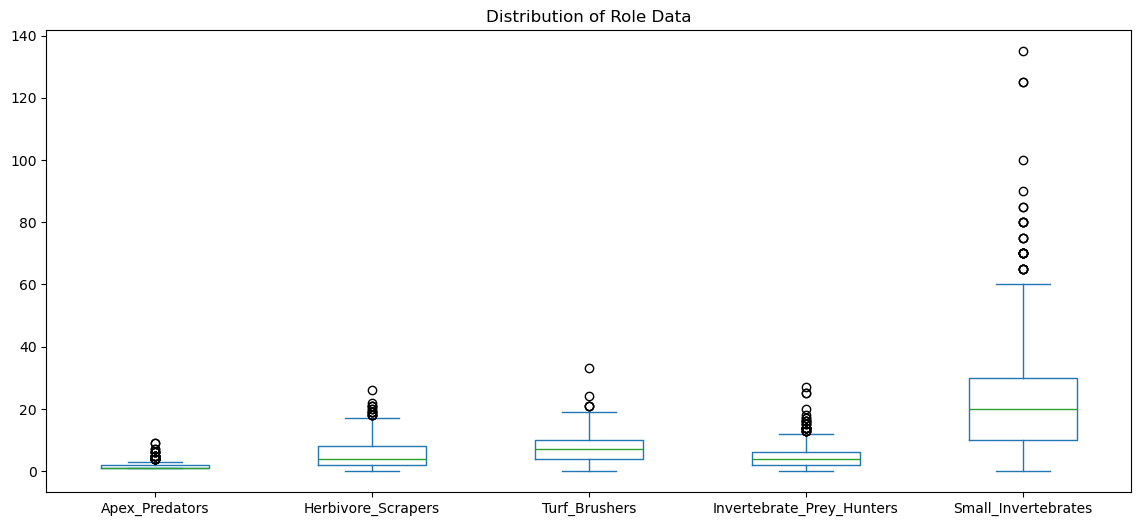

In [24]:
df.plot(kind='box', figsize=(14, 6))
plt.title('Distribution of Role Data')
plt.show()

<hr>

# Model

- The goal of this model is to:
    - intake a list of species counts per 7 roles
    - perform anomaly attribution
    - return a list of species and how much each species contributed to the total anomaly
    - and a total anomaly value.

<hr>

# Plan:
- Since the data is small, tensorflow is not needed.
- The model used will be IF + DIFFI
- IF will be used to detect anomalies, and DIFFI will be used to attribute the anomaly to the features (species) that contributed to it.

### DIFFI
- DIFFI was conceived out of a concern specifically for IF; that it was a black box in terms of which features contributed to the anomaly score.
- Thus, DIFFI is specifically engineered for IF to provide a feature attribution for the anomaly score.
- The details and motivations for DIFFI are described in this paper: https://arxiv.org/abs/2007.11117

### On the topic of preprop:
- Scaling and Normalisation:
    - IF is a threshold model so this is not needed at all.
- Vectorisation:
    - This data is a species count, so it is literally count vectorised.
- Dimensionality reduction:
    - This is not needed as the data is already in a low dimensional space (7 dimensions)
    - Furthermore, this cannot be done anyway because each feature is crucially meaningful and cannot be reduced without partially or entirely losing a species category.
- Sparseness:
    - Sparseness is not an issue because the dataset was engineered to be fully dense!

- Thus, actually, this is a rare case where the df can just be fed into the model as is:

In [25]:
from sklearn.ensemble import IsolationForest

IF = IsolationForest(contamination=0.1, random_state=42)

# due to dataset size there will be 15% test samples only :(
df_train = df.sample(frac=0.85, random_state=42)
df_test = df.drop(df_train.index)

IF.fit(df_train)

IsolationForest(contamination=0.1, random_state=42)

In [26]:
# test the IF first
preds = IF.predict(df_test)

print(preds)

[ 1 -1 -1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1 -1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1
  1  1  1  1  1  1 -1  1 -1 -1]


# DIFFI

- !! The below code is not written by me, it is taken from the DIFFI paper and modified to fit this dataset. I do not claim any credit for this code, and all credit goes to the authors of the DIFFI paper.
- The below code is BSD 3-Clause Licensed, and the original code can be found in the github repo linked to the paper.

- There are two snippets. one is an skl patch to expose a score value and the other is the diffi implementation.

In [27]:
# skl patch

from sklearn.ensemble._iforest import _average_path_length
from sklearn.utils.validation import _num_samples
from sklearn.utils import gen_batches
from sklearn.utils._chunking import get_chunk_n_rows
import numpy as np

def decision_function_single_tree(iforest, tree_idx, X):
    return _score_samples(iforest, tree_idx, X) - iforest.offset_

def _score_samples(iforest, tree_idx, X):
    if iforest.n_features_in_ != X.shape[1]:
        raise ValueError("Number of features of the model must "
                          "match the input. Model n_features is {0} and "
                          "input n_features is {1}."
                          "".format(iforest.n_features_in_, X.shape[1]))
    return -_compute_chunked_score_samples(iforest, tree_idx, X)

def _compute_chunked_score_samples(iforest, tree_idx, X):
    n_samples = _num_samples(X)
    subsample_features = (iforest._max_features != X.shape[1])
    chunk_n_rows = get_chunk_n_rows(row_bytes=16 * iforest._max_features, max_n_rows=n_samples)
    slices = gen_batches(n_samples, chunk_n_rows)
    scores = np.zeros(n_samples, order="f")
    for sl in slices:
        scores[sl] = _compute_score_samples_single_tree(iforest, tree_idx, X[sl], subsample_features)
    return scores

def _compute_score_samples_single_tree(iforest, tree_idx, X, subsample_features):
    n_samples = X.shape[0]
    depths = np.zeros(n_samples, order="f")
    tree = iforest.estimators_[tree_idx]
    features = iforest.estimators_features_[tree_idx]
    X_subset = X[:, features] if subsample_features else X
    leaves_index = tree.apply(X_subset)
    node_indicator = tree.decision_path(X_subset)
    n_samples_leaf = tree.tree_.n_node_samples[leaves_index]
    depths += (np.ravel(node_indicator.sum(axis=1)) + _average_path_length(n_samples_leaf) - 1.0)
    scores = 2 ** (-depths / (1 * _average_path_length([iforest.max_samples_])))
    return scores

In [28]:
# diffi implementation

import time
from math import ceil

def diffi_ib(iforest, X, adjust_iic=True):  # "ib" = in-bag
    start = time.time()
    num_feat = X.shape[1]
    estimators = iforest.estimators_
    cfi_outliers_ib = np.zeros(num_feat).astype('float')
    cfi_inliers_ib = np.zeros(num_feat).astype('float')
    counter_outliers_ib = np.zeros(num_feat).astype('int')
    counter_inliers_ib = np.zeros(num_feat).astype('int')
    in_bag_samples = iforest.estimators_samples_

    for k, estimator in enumerate(estimators):
        in_bag_sample = list(in_bag_samples[k])
        X_ib = X[in_bag_sample, :]
        as_ib = decision_function_single_tree(iforest, k, X_ib)
        X_outliers_ib = X_ib[np.where(as_ib < 0)]
        X_inliers_ib = X_ib[np.where(as_ib > 0)]
        if X_inliers_ib.shape[0] == 0 or X_outliers_ib.shape[0] == 0:
            continue

        n_nodes = estimator.tree_.node_count
        children_left = estimator.tree_.children_left
        children_right = estimator.tree_.children_right
        feature = estimator.tree_.feature
        node_depth = np.zeros(shape=n_nodes, dtype=np.int64)
        is_leaves = np.zeros(shape=n_nodes, dtype=bool)

        stack = [(0, -1)]
        while len(stack) > 0:
            node_id, parent_depth = stack.pop()
            node_depth[node_id] = parent_depth + 1
            if children_left[node_id] != children_right[node_id]:
                stack.append((children_left[node_id], parent_depth + 1))
                stack.append((children_right[node_id], parent_depth + 1))
            else:
                is_leaves[node_id] = True

        # OUTLIERS
        lambda_outliers_ib = _get_iic(estimator, X_outliers_ib, is_leaves, adjust_iic)
        node_indicator_all_points_outliers_ib = estimator.decision_path(X_outliers_ib)
        node_indicator_all_points_array_outliers_ib = node_indicator_all_points_outliers_ib.toarray()
        for i in range(len(X_outliers_ib)):
            path = list(np.where(node_indicator_all_points_array_outliers_ib[i] == 1)[0])
            depth = node_depth[path[-1]]
            for node in path:
                current_feature = feature[node]
                if lambda_outliers_ib[node] == -1:
                    continue
                else:
                    cfi_outliers_ib[current_feature] += (1 / depth) * lambda_outliers_ib[node]
                    counter_outliers_ib[current_feature] += 1

        # INLIERS
        lambda_inliers_ib = _get_iic(estimator, X_inliers_ib, is_leaves, adjust_iic)
        node_indicator_all_points_inliers_ib = estimator.decision_path(X_inliers_ib)
        node_indicator_all_points_array_inliers_ib = node_indicator_all_points_inliers_ib.toarray()
        for i in range(len(X_inliers_ib)):
            path = list(np.where(node_indicator_all_points_array_inliers_ib[i] == 1)[0])
            depth = node_depth[path[-1]]
            for node in path:
                current_feature = feature[node]
                if lambda_inliers_ib[node] == -1:
                    continue
                else:
                    cfi_inliers_ib[current_feature] += (1 / depth) * lambda_inliers_ib[node]
                    counter_inliers_ib[current_feature] += 1

    fi_outliers_ib = np.where(counter_outliers_ib > 0, cfi_outliers_ib / counter_outliers_ib, 0)
    fi_inliers_ib = np.where(counter_inliers_ib > 0, cfi_inliers_ib / counter_inliers_ib, 0)
    fi_ib = fi_outliers_ib / fi_inliers_ib

    exec_time = time.time() - start
    return fi_ib, exec_time


def local_diffi(iforest, x):
    start = time.time()
    estimators = iforest.estimators_
    cfi = np.zeros(len(x)).astype('float')
    counter = np.zeros(len(x)).astype('int')
    max_depth = int(np.ceil(np.log2(iforest.max_samples_)))

    for estimator in estimators:
        n_nodes = estimator.tree_.node_count
        children_left = estimator.tree_.children_left
        children_right = estimator.tree_.children_right
        feature = estimator.tree_.feature
        node_depth = np.zeros(shape=n_nodes, dtype=np.int64)
        is_leaves = np.zeros(shape=n_nodes, dtype=bool)

        stack = [(0, -1)]
        while len(stack) > 0:
            node_id, parent_depth = stack.pop()
            node_depth[node_id] = parent_depth + 1
            if children_left[node_id] != children_right[node_id]:
                stack.append((children_left[node_id], parent_depth + 1))
                stack.append((children_right[node_id], parent_depth + 1))
            else:
                is_leaves[node_id] = True

        x_reshaped = x.reshape(1, -1)
        node_indicator = estimator.decision_path(x_reshaped)
        node_indicator_array = node_indicator.toarray()
        path = list(np.where(node_indicator_array == 1)[1])
        leaf_depth = node_depth[path[-1]]
        for node in path:
            if not is_leaves[node]:
                current_feature = feature[node]
                cfi[current_feature] += (1 / leaf_depth) - (1 / max_depth)
                counter[current_feature] += 1

    fi = np.zeros(len(cfi))
    for i in range(len(cfi)):
        if counter[i] != 0:
            fi[i] = cfi[i] / counter[i]

    exec_time = time.time() - start
    return fi, exec_time


def _get_iic(estimator, predictions, is_leaves, adjust_iic):
    desired_min, desired_max, epsilon = 0.5, 1.0, 0.0
    n_nodes = estimator.tree_.node_count
    lambda_ = np.zeros(n_nodes)
    children_left = estimator.tree_.children_left
    children_right = estimator.tree_.children_right
    node_indicator_all_samples = estimator.decision_path(predictions).toarray()
    num_samples_in_node = np.sum(node_indicator_all_samples, axis=0)

    for node in range(n_nodes):
        num_samples_in_current_node = num_samples_in_node[node]
        num_samples_in_left_children = num_samples_in_node[children_left[node]]
        num_samples_in_right_children = num_samples_in_node[children_right[node]]

        if num_samples_in_current_node == 0 or num_samples_in_current_node == 1 or is_leaves[node]:
            lambda_[node] = -1
        elif num_samples_in_left_children == 0 or num_samples_in_right_children == 0:
            lambda_[node] = epsilon
        else:
            if num_samples_in_current_node % 2 == 0:
                current_min = 0.5
            else:
                current_min = ceil(num_samples_in_current_node / 2) / num_samples_in_current_node
            current_max = (num_samples_in_current_node - 1) / num_samples_in_current_node
            tmp = np.max([num_samples_in_left_children, num_samples_in_right_children]) / num_samples_in_current_node
            if adjust_iic and current_min != current_max:
                lambda_[node] = ((tmp - current_min) / (current_max - current_min)) * (desired_max - desired_min) + desired_min
            else:
                lambda_[node] = tmp
    return lambda_

# DIFFI on IF

- The below code here explains which role in the dataset GLOBALLY contributed to the anomaly score entirely.

In [29]:
fi_ib, exec_time = diffi_ib(IF, df_train.values)
pd.Series(fi_ib, index=df_train.columns).sort_values(ascending=False).head(15)

Apex_Predators               2.204957
Invertebrate_Prey_Hunters    1.487777
Herbivore_Scrapers           1.484401
Turf_Brushers                1.465176
Small_Invertebrates          1.405699
dtype: float64

- for a local score, local_diffi:

In [30]:
# pick a specific row to explain, e.g. the first flagged anomaly in df_test
preds = IF.predict(df_test)
anomaly_rows = df_test[preds == -1]

x = anomaly_rows.iloc[0].values   # numpy array, one sample

fi, exec_time = local_diffi(IF, x)

pd.Series(fi, index=df_test.columns).sort_values(ascending=False).head(15)

Apex_Predators               0.015476
Herbivore_Scrapers           0.012180
Turf_Brushers                0.011874
Invertebrate_Prey_Hunters    0.010803
Small_Invertebrates          0.010794
dtype: float64

<hr>

# Model Evaluation & Scoring

## 1. Test Set Predictions & Anomaly Detection

In [31]:
# Get predictions and anomaly scores on test set
test_predictions = IF.predict(df_test)
test_scores = IF.score_samples(df_test)

# Create results dataframe
eval_results = df_test.copy()
eval_results['Anomaly_Flag'] = test_predictions
eval_results['Anomaly_Score'] = test_scores
eval_results['Label'] = eval_results['Anomaly_Flag'].apply(lambda x: 'Anomaly' if x == -1 else 'Normal')

print("Test Set Results:")
print(f"Total Samples: {len(eval_results)}")
print(f"Normal Samples: {(eval_results['Anomaly_Flag'] == 1).sum()}")
print(f"Anomalies Detected: {(eval_results['Anomaly_Flag'] == -1).sum()}")
print(f"\nAnomalies as % of test set: {100 * (eval_results['Anomaly_Flag'] == -1).sum() / len(eval_results):.2f}%")

display(eval_results[['Anomaly_Flag', 'Anomaly_Score', 'Label']].head(10))

Test Set Results:
Total Samples: 106
Normal Samples: 97
Anomalies Detected: 9

Anomalies as % of test set: 8.49%


,Anomaly_Flag,Anomaly_Score,Label
85,1,-0.516543,Normal
80,-1,-0.555754,Anomaly
680,-1,-0.611339,Anomaly
683,1,-0.508795,Normal
595,1,-0.510946,Normal
621,1,-0.481879,Normal
222,-1,-0.557732,Anomaly
78,1,-0.463168,Normal
240,1,-0.497096,Normal
667,1,-0.503030,Normal


## 2. Anomaly Score Statistics

In [32]:
# Score statistics
print("Anomaly Score Statistics:")
print(f"Mean Score: {test_scores.mean():.4f}")
print(f"Std Dev: {test_scores.std():.4f}")
print(f"Min Score: {test_scores.min():.4f}")
print(f"Max Score: {test_scores.max():.4f}")
print(f"Median Score: {np.median(test_scores):.4f}")

# Separate normal vs anomaly scores
normal_scores = test_scores[test_predictions == 1]
anomaly_scores = test_scores[test_predictions == -1]

print(f"\nNormal Samples - Mean: {normal_scores.mean():.4f}, Std: {normal_scores.std():.4f}")
print(f"Anomalies - Mean: {anomaly_scores.mean():.4f}, Std: {anomaly_scores.std():.4f}")

Anomaly Score Statistics:
Mean Score: -0.4623
Std Dev: 0.0620
Min Score: -0.7603
Max Score: -0.3833
Median Score: -0.4497

Normal Samples - Mean: -0.4489, Std: 0.0420
Anomalies - Mean: -0.6066, Std: 0.0589


## 3. Score Distribution Visualization

C:\Users\thefa\AppData\Local\Temp\ipykernel_22860\1923261277.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(box_data, labels=box_labels, patch_artist=True)


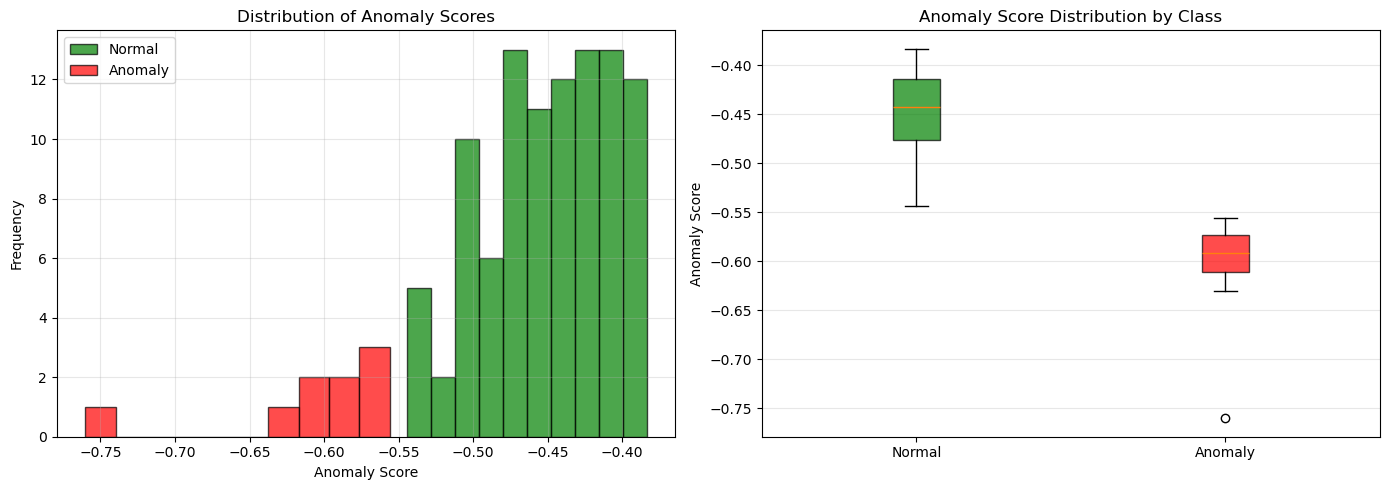

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of all scores
axes[0].hist(normal_scores, bins=10, alpha=0.7, label='Normal', color='green', edgecolor='black')
if len(anomaly_scores) > 0:
    axes[0].hist(anomaly_scores, bins=10, alpha=0.7, label='Anomaly', color='red', edgecolor='black')
axes[0].set_xlabel('Anomaly Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Anomaly Scores')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot
box_data = [normal_scores]
box_labels = ['Normal']
if len(anomaly_scores) > 0:
    box_data.append(anomaly_scores)
    box_labels.append('Anomaly')

bp = axes[1].boxplot(box_data, labels=box_labels, patch_artist=True)
colors = ['green', 'red']
for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel('Anomaly Score')
axes[1].set_title('Anomaly Score Distribution by Class')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 4. Detailed Anomaly Analysis

In [34]:
# Get all detected anomalies
anomalies = eval_results[eval_results['Anomaly_Flag'] == -1].copy()

print(f"\n=== DETECTED ANOMALIES ===")
print(f"Total Anomalies: {len(anomalies)}\n")

if len(anomalies) > 0:
    # Sort by anomaly score (more negative = more anomalous)
    anomalies = anomalies.sort_values('Anomaly_Score')
    
    # Display anomalies
    role_cols = ['Apex_Predators', 'Herbivore_Scrapers', 'Turf_Brushers', 'Invertebrate_Prey_Hunters', 'Small_Invertebrates']
    display(anomalies[role_cols + ['Anomaly_Score']])
else:
    print("No anomalies detected in test set.")


=== DETECTED ANOMALIES ===
Total Anomalies: 9



,Apex_Predators,Herbivore_Scrapers,Turf_Brushers,Invertebrate_Prey_Hunters,Small_Invertebrates,Anomaly_Score
508,1,26,0,25,125,-0.760319
406,1,5,3,18,90,-0.630107
680,6,1,2,1,5,-0.611339
371,1,20,0,5,25,-0.598267
137,5,7,7,9,45,-0.592121
120,1,1,8,14,70,-0.579920
774,4,3,8,10,50,-0.573516
222,5,2,9,1,5,-0.557732
80,3,4,0,0,0,-0.555754


## 5. Feature Attribution for Detected Anomalies

In [35]:
if len(anomalies) > 0:
    print("\n=== LOCAL FEATURE ATTRIBUTION ===")
    print("Top contributing features for each detected anomaly:\n")
    
    for idx, (i, row) in enumerate(anomalies.iterrows()):
        x = row[['Apex_Predators', 'Herbivore_Scrapers', 'Turf_Brushers', 'Invertebrate_Prey_Hunters', 'Small_Invertebrates']].values
        fi, _ = local_diffi(IF, x)
        attribution = pd.Series(fi, index=['Apex_Predators', 'Herbivore_Scrapers', 'Turf_Brushers', 'Invertebrate_Prey_Hunters', 'Small_Invertebrates']).sort_values(ascending=False)
        
        print(f"Anomaly {idx + 1} (Score: {row['Anomaly_Score']:.4f}):")
        print(attribution)
        print()


=== LOCAL FEATURE ATTRIBUTION ===
Top contributing features for each detected anomaly:

Anomaly 1 (Score: -0.7603):
Small_Invertebrates          0.173387
Invertebrate_Prey_Hunters    0.150401
Herbivore_Scrapers           0.103444
Turf_Brushers                0.085085
Apex_Predators               0.078589
dtype: float64

Anomaly 2 (Score: -0.6301):
Invertebrate_Prey_Hunters    0.080723
Small_Invertebrates          0.056190
Herbivore_Scrapers           0.031905
Apex_Predators               0.031497
Turf_Brushers                0.024131
dtype: float64

Anomaly 3 (Score: -0.6113):
Apex_Predators               0.076919
Small_Invertebrates          0.035931
Turf_Brushers                0.027219
Herbivore_Scrapers           0.025472
Invertebrate_Prey_Hunters    0.023584
dtype: float64

Anomaly 4 (Score: -0.5983):
Herbivore_Scrapers           0.042191
Turf_Brushers                0.025735
Invertebrate_Prey_Hunters    0.022972
Small_Invertebrates          0.022970
Apex_Predators               

## 6. Global Feature Importance


=== GLOBAL FEATURE IMPORTANCE ===
Features ranked by contribution to anomaly detection:



Apex_Predators               2.204957
Invertebrate_Prey_Hunters    1.487777
Herbivore_Scrapers           1.484401
Turf_Brushers                1.465176
Small_Invertebrates          1.405699
dtype: float64

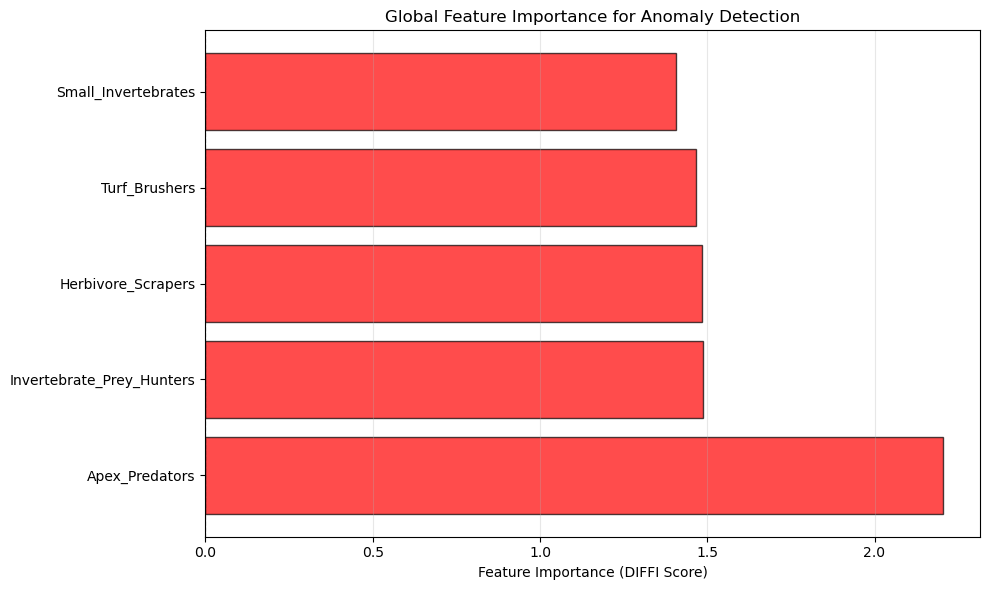

In [36]:
# Calculate global feature importance using DIFFI
fi_global, exec_time = diffi_ib(IF, df_train.values)
global_importance = pd.Series(fi_global, index=df_train.columns).sort_values(ascending=False)

print("\n=== GLOBAL FEATURE IMPORTANCE ===")
print("Features ranked by contribution to anomaly detection:\n")
display(global_importance)

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['red' if x > 0 else 'blue' for x in global_importance.values]
bars = ax.barh(range(len(global_importance)), global_importance.values, color=colors, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(global_importance)))
ax.set_yticklabels(global_importance.index)
ax.set_xlabel('Feature Importance (DIFFI Score)')
ax.set_title('Global Feature Importance for Anomaly Detection')
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 7. Comparison: Normal vs Anomalies

In [37]:
# Compare role distributions
role_cols = ['Apex_Predators', 'Herbivore_Scrapers', 'Turf_Brushers', 'Invertebrate_Prey_Hunters', 'Small_Invertebrates']

normal_samples = eval_results[eval_results['Anomaly_Flag'] == 1][role_cols]
anomaly_samples = eval_results[eval_results['Anomaly_Flag'] == -1][role_cols]

print("\n=== ROLE DISTRIBUTION COMPARISON ===")
print("\nNormal Samples - Statistics:")
print(normal_samples.describe())

if len(anomaly_samples) > 0:
    print("\nAnomalous Samples - Statistics:")
    print(anomaly_samples.describe())

    # Mean comparison
    comparison = pd.DataFrame({
        'Normal_Mean': normal_samples.mean(),
        'Anomaly_Mean': anomaly_samples.mean(),
    })
    comparison['Difference'] = comparison['Anomaly_Mean'] - comparison['Normal_Mean']
    comparison['% Difference'] = (comparison['Difference'] / comparison['Normal_Mean'] * 100).round(2)
    
    print("\nMean Comparison:")
    display(comparison)


=== ROLE DISTRIBUTION COMPARISON ===

Normal Samples - Statistics:
       Apex_Predators  Herbivore_Scrapers  Turf_Brushers  \
count       97.000000           97.000000      97.000000   
mean         1.360825            5.030928       7.402062   
std          0.738602            3.649925       4.676314   
min          1.000000            0.000000       0.000000   
25%          1.000000            2.000000       4.000000   
50%          1.000000            5.000000       7.000000   
75%          1.000000            7.000000      10.000000   
max          4.000000           19.000000      24.000000   

       Invertebrate_Prey_Hunters  Small_Invertebrates  
count                  97.000000            97.000000  
mean                    3.639175            18.195876  
std                     2.754487            13.772436  
min                     0.000000             0.000000  
25%                     2.000000            10.000000  
50%                     3.000000            15.000000  

,Normal_Mean,Anomaly_Mean,Difference,% Difference
Apex_Predators,1.360825,3.000000,1.639175,120.45
Herbivore_Scrapers,5.030928,7.666667,2.635739,52.39
Turf_Brushers,7.402062,4.111111,-3.290951,-44.46
Invertebrate_Prey_Hunters,3.639175,9.222222,5.583047,153.42
Small_Invertebrates,18.195876,46.111111,27.915235,153.42


## 8. Visual Comparison

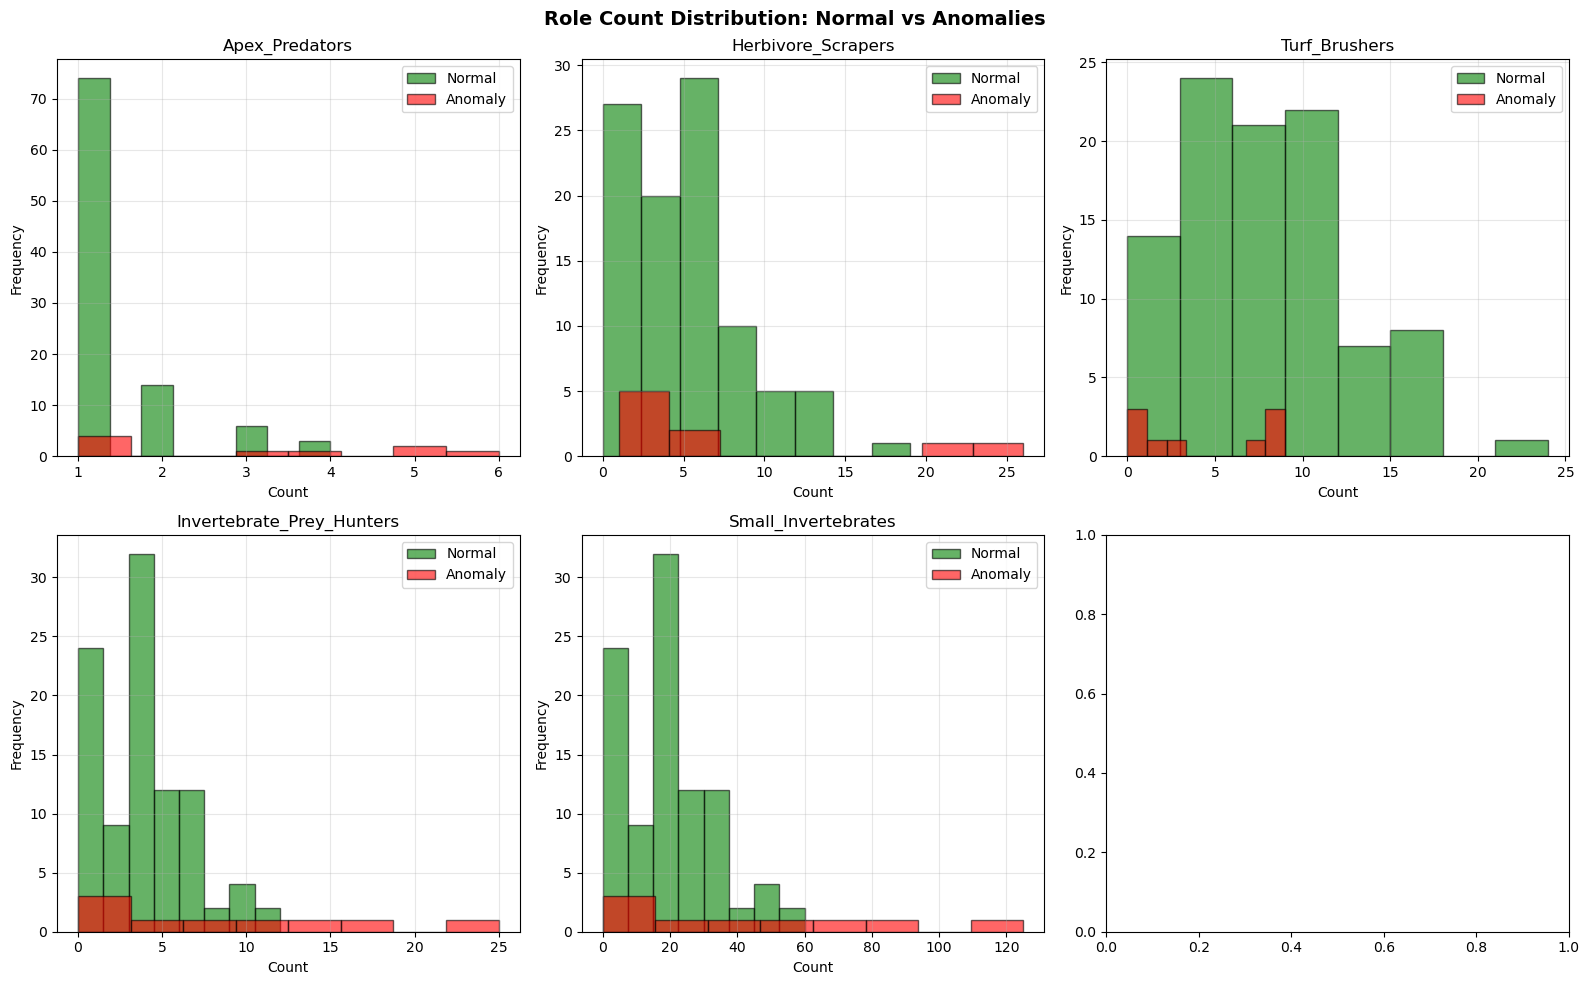

In [38]:
if len(anomaly_samples) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    
    for idx, role in enumerate(role_cols):
        axes[idx].hist(normal_samples[role], bins=8, alpha=0.6, label='Normal', color='green', edgecolor='black')
        axes[idx].hist(anomaly_samples[role], bins=8, alpha=0.6, label='Anomaly', color='red', edgecolor='black')
        axes[idx].set_xlabel('Count')
        axes[idx].set_ylabel('Frequency')
        axes[idx].set_title(f'{role}')
        axes[idx].legend()
        axes[idx].grid(alpha=0.3)
    
    plt.suptitle('Role Count Distribution: Normal vs Anomalies', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 9. Model Performance Summary

In [39]:
print("\n" + "="*60)
print("MODEL EVALUATION SUMMARY")
print("="*60)

print("\n[DATASET]")
print(f"Training Samples: {len(df_train)}")
print(f"Test Samples: {len(df_test)}")
print(f"Total Features (Roles): {len(role_cols)}")

print("\n[ISOLATION FOREST CONFIGURATION]")
print(f"Contamination Rate: 0.1 (10%)")
print(f"Max Samples: {IF.max_samples_}")
print(f"Number of Trees: {IF.n_estimators}")

print("\n[TEST SET RESULTS]")
n_normal = (test_predictions == 1).sum()
n_anomalies = (test_predictions == -1).sum()
print(f"Normal Samples: {n_normal} ({100*n_normal/len(test_predictions):.1f}%)")
print(f"Anomalies Detected: {n_anomalies} ({100*n_anomalies/len(test_predictions):.1f}%)")

print("\n[ANOMALY SCORE RANGES]")
print(f"Normal Samples Score Range: [{normal_scores.min():.4f}, {normal_scores.max():.4f}]")
print(f"Normal Mean Score: {normal_scores.mean():.4f} ± {normal_scores.std():.4f}")
if len(anomaly_scores) > 0:
    print(f"Anomaly Score Range: [{anomaly_scores.min():.4f}, {anomaly_scores.max():.4f}]")
    print(f"Anomaly Mean Score: {anomaly_scores.mean():.4f} ± {anomaly_scores.std():.4f}")

print("\n[TOP CONTRIBUTING FEATURES (Global DIFFI)]")
print(global_importance.head(3))

print("\n[KEY INSIGHTS]")
if n_anomalies == 0:
    print("• No anomalies detected in test set")
    print("• All survey samples appear normal relative to training distribution")
else:
    print(f"• {n_anomalies} anomalous survey(s) identified")
    most_imp_roles = comparison['% Difference'].abs().nlargest(3)
    for role, pct_diff in most_imp_roles.items():
        print(f"• {role}: {pct_diff:.1f}% difference between normal and anomalies")

print("\n" + "="*60)


MODEL EVALUATION SUMMARY

[DATASET]
Training Samples: 598
Test Samples: 106
Total Features (Roles): 5

[ISOLATION FOREST CONFIGURATION]
Contamination Rate: 0.1 (10%)
Max Samples: 256
Number of Trees: 100

[TEST SET RESULTS]
Normal Samples: 97 (91.5%)
Anomalies Detected: 9 (8.5%)

[ANOMALY SCORE RANGES]
Normal Samples Score Range: [-0.5441, -0.3833]
Normal Mean Score: -0.4489 ± 0.0420
Anomaly Score Range: [-0.7603, -0.5558]
Anomaly Mean Score: -0.6066 ± 0.0589

[TOP CONTRIBUTING FEATURES (Global DIFFI)]
Apex_Predators               2.204957
Invertebrate_Prey_Hunters    1.487777
Herbivore_Scrapers           1.484401
dtype: float64

[KEY INSIGHTS]
• 9 anomalous survey(s) identified
• Invertebrate_Prey_Hunters: 153.4% difference between normal and anomalies
• Small_Invertebrates: 153.4% difference between normal and anomalies
• Apex_Predators: 120.5% difference between normal and anomalies



In [ ]:
import joblib
from math import ceil
import time

FEATURE_ORDER = [
    "Apex_Predators",
    "Herbivore_Scrapers",
    "Turf_Brushers",
    "Invertebrate_Prey_Hunters",
    "Small_Invertebrates",
]


def decision_function_single_tree(iforest, tree_idx, X):
    return _score_samples(iforest, tree_idx, X) - iforest.offset_


def _score_samples(iforest, tree_idx, X):
    if iforest.n_features_in_ != X.shape[1]:
        raise ValueError(
            f"Number of features of the model must match the input. "
            f"Model n_features is {iforest.n_features_in_} and input n_features is {X.shape[1]}."
        )
    return -_compute_chunked_score_samples(iforest, tree_idx, X)


def _compute_chunked_score_samples(iforest, tree_idx, X):
    from sklearn.utils.validation import _num_samples
    from sklearn.utils import gen_batches
    from sklearn.utils._chunking import get_chunk_n_rows
    from sklearn.ensemble._iforest import _average_path_length

    n_samples = _num_samples(X)
    subsample_features = (iforest._max_features != X.shape[1])
    chunk_n_rows = get_chunk_n_rows(
        row_bytes=16 * iforest._max_features, max_n_rows=n_samples)
    slices = gen_batches(n_samples, chunk_n_rows)
    scores = np.zeros(n_samples, order="f")
    for sl in slices:
        scores[sl] = _compute_score_samples_single_tree(
            iforest, tree_idx, X[sl], subsample_features
        )
    return scores


def _compute_score_samples_single_tree(iforest, tree_idx, X, subsample_features):
    from sklearn.ensemble._iforest import _average_path_length

    n_samples = X.shape[0]
    depths = np.zeros(n_samples, order="f")
    tree = iforest.estimators_[tree_idx]
    features = iforest.estimators_features_[tree_idx]
    X_subset = X[:, features] if subsample_features else X
    leaves_index = tree.apply(X_subset)
    node_indicator = tree.decision_path(X_subset)
    n_samples_leaf = tree.tree_.n_node_samples[leaves_index]
    depths += (np.ravel(node_indicator.sum(axis=1)) +
               _average_path_length(n_samples_leaf) - 1.0)
    scores = 2 ** (-depths /
                   (1 * _average_path_length([iforest.max_samples_])))
    return scores


def _get_iic(estimator, predictions, is_leaves, adjust_iic):
    desired_min, desired_max, epsilon = 0.5, 1.0, 0.0
    n_nodes = estimator.tree_.node_count
    lambda_ = np.zeros(n_nodes)
    children_left = estimator.tree_.children_left
    children_right = estimator.tree_.children_right
    node_indicator_all_samples = estimator.decision_path(predictions).toarray()
    num_samples_in_node = np.sum(node_indicator_all_samples, axis=0)

    for node in range(n_nodes):
        num_samples_in_current_node = num_samples_in_node[node]
        num_samples_in_left_children = num_samples_in_node[children_left[node]]
        num_samples_in_right_children = num_samples_in_node[children_right[node]]

        if num_samples_in_current_node == 0 or num_samples_in_current_node == 1 or is_leaves[node]:
            lambda_[node] = -1
        elif num_samples_in_left_children == 0 or num_samples_in_right_children == 0:
            lambda_[node] = epsilon
        else:
            if num_samples_in_current_node % 2 == 0:
                current_min = 0.5
            else:
                current_min = ceil(num_samples_in_current_node /
                                   2) / num_samples_in_current_node
            current_max = (num_samples_in_current_node - 1) / \
                num_samples_in_current_node
            tmp = np.max([num_samples_in_left_children,
                         num_samples_in_right_children]) / num_samples_in_current_node
            if adjust_iic and current_min != current_max:
                lambda_[node] = ((tmp - current_min) / (current_max -
                                 current_min)) * (desired_max - desired_min) + desired_min
            else:
                lambda_[node] = tmp
    return lambda_


def local_diffi(iforest, x):
    start = time.time()
    estimators = iforest.estimators_
    cfi = np.zeros(len(x)).astype("float")
    counter = np.zeros(len(x)).astype("int")
    max_depth = int(np.ceil(np.log2(iforest.max_samples_)))

    for estimator in estimators:
        n_nodes = estimator.tree_.node_count
        children_left = estimator.tree_.children_left
        children_right = estimator.tree_.children_right
        feature = estimator.tree_.feature
        node_depth = np.zeros(shape=n_nodes, dtype=np.int64)
        is_leaves = np.zeros(shape=n_nodes, dtype=bool)

        stack = [(0, -1)]
        while len(stack) > 0:
            node_id, parent_depth = stack.pop()
            node_depth[node_id] = parent_depth + 1
            if children_left[node_id] != children_right[node_id]:
                stack.append((children_left[node_id], parent_depth + 1))
                stack.append((children_right[node_id], parent_depth + 1))
            else:
                is_leaves[node_id] = True

        x_reshaped = x.reshape(1, -1)
        node_indicator = estimator.decision_path(x_reshaped)
        node_indicator_array = node_indicator.toarray()
        path = list(np.where(node_indicator_array == 1)[1])
        leaf_depth = node_depth[path[-1]]
        for node in path:
            if not is_leaves[node]:
                current_feature = feature[node]
                cfi[current_feature] += (1 / leaf_depth) - (1 / max_depth)
                counter[current_feature] += 1

    fi = np.zeros(len(cfi))
    for i in range(len(cfi)):
        if counter[i] != 0:
            fi[i] = cfi[i] / counter[i]

    exec_time = time.time() - start
    return fi, exec_time


def prepare_input(data):
    df = pd.DataFrame(data)
    missing = [col for col in FEATURE_ORDER if col not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")
    return df[FEATURE_ORDER].astype(float)


class IFDiffiPackage:
    def __init__(self, model, feature_order):
        self.model = model
        self.feature_order = list(feature_order)

    def predict_one(self, row):
        X = prepare_input([row])[self.feature_order]
        x = X.iloc[0].to_numpy()

        pred = int(self.model.predict(X)[0])
        score = float(self.model.score_samples(X)[0])
        diffi_scores, exec_time = local_diffi(self.model, x)

        return {
            "prediction": pred,
            "anomaly_score": score,
            "diffi_scores": dict(zip(self.feature_order, diffi_scores.tolist())),
            "diffi_runtime_sec": float(exec_time),
        }

    def predict_batch(self, data):
        X = prepare_input(data)[self.feature_order]
        preds = self.model.predict(X)
        scores = self.model.score_samples(X)

        diffi_out = []
        for i in range(len(X)):
            fi, exec_time = local_diffi(self.model, X.iloc[i].to_numpy())
            diffi_out.append({
                "prediction": int(preds[i]),
                "anomaly_score": float(scores[i]),
                "diffi_scores": dict(zip(self.feature_order, fi.tolist())),
                "diffi_runtime_sec": float(exec_time),
            })
        return diffi_out


def export_package(iforest, path="sharksphere_if_diffi.joblib"):
    package = IFDiffiPackage(iforest, FEATURE_ORDER)
    joblib.dump(package, path)
    return path


def load_package(path="sharksphere_if_diffi.joblib"):
    return joblib.load(path)

# after training:
# export_package(IF, "sharksphere_if_diffi.joblib")

# usage anywhere in Python:
# pkg = load_package("sharksphere_if_diffi.joblib")
# result = pkg.predict_one({
#     "Apex_Predators": 4,
#     "Herbivore_Scrapers": 18,
#     "Turf_Brushers": 12,
#     "Invertebrate_Prey_Hunters": 7,
#     "Small_Invertebrates": 35,
# })
# print(result)

In [41]:
export_package(IF, "sharksphere_if_diffi.joblib")

'sharksphere_if_diffi.joblib'